In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import folium
from pathlib import Path

In [2]:
BASE_DIR = Path("..")

DATA_DIR = BASE_DIR / "data" / "processed" / "week-3"
VIS_DIR = BASE_DIR / "reports" / "week-3" / "visualizations"

VIS_DIR.mkdir(parents=True, exist_ok=True)

NODES_FILE = DATA_DIR / "graph_node_features.csv"
TARGETS_FILE = DATA_DIR / "graph_targets.csv"
EDGES_FILE = DATA_DIR / "knn_graph_edges.csv"

In [3]:
nodes_df = pd.read_csv(NODES_FILE)
targets_df = pd.read_csv(TARGETS_FILE)
edges_df = pd.read_csv(EDGES_FILE)

print("Nodes:", nodes_df.shape)
print("Targets:", targets_df.shape)
print("Edges:", edges_df.shape)

print("\nNode columns:")
print(nodes_df.columns.tolist())

print("\nEdge columns:")
print(edges_df.columns.tolist())

Nodes: (21613, 18)
Targets: (21613, 2)
Edges: (108065, 3)

Node columns:
['node_id', 'id', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'House Age', 'yr_built', 'yr_renovated', 'lat', 'long']

Edge columns:
['source', 'target', 'distance_km']


In [4]:
print("Missing values in nodes:")
print(nodes_df.isnull().sum().sum())

print("\nMissing values in edges:")
print(edges_df.isnull().sum().sum())

print("\nMissing values in targets:")
print(targets_df.isnull().sum().sum())

Missing values in nodes:
0

Missing values in edges:
0

Missing values in targets:
0


In [5]:
node_ids = set(nodes_df["node_id"])

invalid_sources = edges_df.loc[~edges_df["source"].isin(node_ids)]

invalid_targets = edges_df.loc[~edges_df["target"].isin(node_ids)]

print("Invalid source IDs:", len(invalid_sources))
print("Invalid target IDs:", len(invalid_targets))

Invalid source IDs: 0
Invalid target IDs: 0


In [6]:
self_loops = edges_df[edges_df["source"] == edges_df["target"]]

print("Number of self-loops:", len(self_loops))

Number of self-loops: 0


In [7]:
duplicate_edges = edges_df.duplicated(subset=["source", "target"]).sum()

print("Duplicate edges:", duplicate_edges)

Duplicate edges: 0


In [8]:
print("Minimum distance:", edges_df["distance_km"].min())
print("Maximum distance:", edges_df["distance_km"].max())
print("Mean distance:", edges_df["distance_km"].mean())
print("Median distance:", edges_df["distance_km"].median())

negative_distances = (edges_df["distance_km"] < 0).sum()

missing_distances = edges_df["distance_km"].isna().sum()

print("\nNegative distances:", negative_distances)
print("Missing distances:", missing_distances)

Minimum distance: 0.0
Maximum distance: 23.51797641606095
Mean distance: 0.1963245963779268
Median distance: 0.1537400366214734

Negative distances: 0
Missing distances: 0


In [9]:
out_degree = (edges_df.groupby("source").size().rename("out_degree"))

print(out_degree.describe())

count    21613.0
mean         5.0
std          0.0
min          5.0
25%          5.0
50%          5.0
75%          5.0
max          5.0
Name: out_degree, dtype: float64


In [10]:
expected_nodes = set(nodes_df["node_id"])
nodes_with_edges = set(out_degree.index)

missing_nodes = expected_nodes - nodes_with_edges

print("Nodes without outgoing edges:", len(missing_nodes))

incorrect_degree = out_degree[out_degree != 5]

print("Nodes with degree other than 5:", len(incorrect_degree))

Nodes without outgoing edges: 0
Nodes with degree other than 5: 0


In [11]:
in_degree = (edges_df.groupby("target").size().rename("in_degree"))

node_degree_df = pd.DataFrame({
    "node_id": nodes_df["node_id"],
    "out_degree": nodes_df["node_id"].map(out_degree).fillna(0),
    "in_degree": nodes_df["node_id"].map(in_degree).fillna(0)
})

node_degree_df.head()

,node_id,out_degree,in_degree
0,0,5,6.0
1,1,5,7.0
2,2,5,6.0
3,3,5,3.0
4,4,5,6.0


In [12]:
print("Outgoing Degree Statistics")
print(node_degree_df["out_degree"].describe())

print("\nIncoming Degree Statistics")
print(node_degree_df["in_degree"].describe())

Outgoing Degree Statistics
count    21613.0
mean         5.0
std          0.0
min          5.0
25%          5.0
50%          5.0
75%          5.0
max          5.0
Name: out_degree, dtype: float64

Incoming Degree Statistics
count    21613.000000
mean         5.000000
std          1.937364
min          0.000000
25%          4.000000
50%          5.000000
75%          6.000000
max         12.000000
Name: in_degree, dtype: float64


In [13]:
top_connected_nodes = (node_degree_df.sort_values("in_degree", ascending=False).head(10))

top_connected_nodes

,node_id,out_degree,in_degree
7138,7138,5,12.0
8246,8246,5,12.0
6937,6937,5,12.0
21107,21107,5,12.0
11318,11318,5,12.0
1994,1994,5,11.0
2002,2002,5,11.0
2126,2126,5,11.0
5111,5111,5,11.0
11408,11408,5,11.0


In [14]:
distance_statistics = pd.DataFrame({
    "metric": [
        "minimum",
        "maximum",
        "mean",
        "median",
        "standard_deviation"
    ],
    "distance_km": [
        edges_df["distance_km"].min(),
        edges_df["distance_km"].max(),
        edges_df["distance_km"].mean(),
        edges_df["distance_km"].median(),
        edges_df["distance_km"].std()
    ]
})

distance_statistics

,metric,distance_km
0,minimum,0.000000
1,maximum,23.517976
2,mean,0.196325
3,median,0.153740
4,standard_deviation,0.300451


In [15]:
distance_statistics.to_csv(DATA_DIR / "graph_distance_statistics.csv",index=False)

print("✅ Distance statistics saved.")

✅ Distance statistics saved.


In [16]:
node_degree_df.to_csv(DATA_DIR / "graph_node_statistics.csv",index=False)

print("✅ Node statistics saved.")

✅ Node statistics saved.


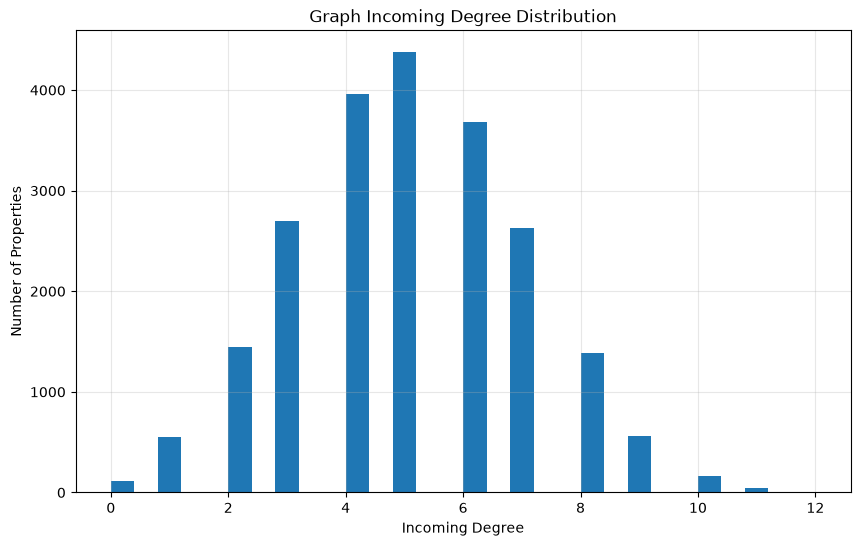

✅ Saved: ..\reports\week-3\visualizations\node_degree_distribution.png


In [17]:
degree_plot_path = VIS_DIR / "node_degree_distribution.png"

plt.figure(figsize=(10, 6))

plt.hist(node_degree_df["in_degree"],bins=30)

plt.xlabel("Incoming Degree")
plt.ylabel("Number of Properties")
plt.title("Graph Incoming Degree Distribution")
plt.grid(alpha=0.3)

plt.savefig(degree_plot_path,dpi=150,bbox_inches="tight")

plt.show()

print(f"✅ Saved: {degree_plot_path}")

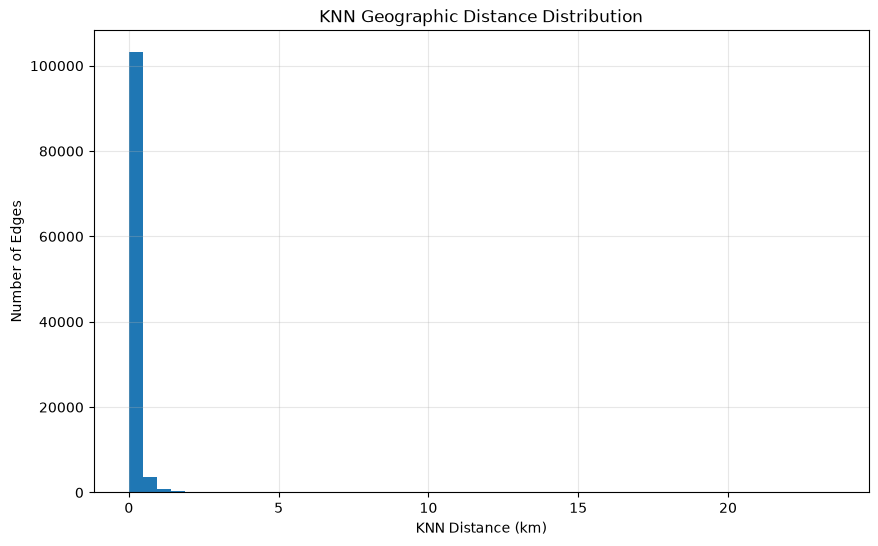

✅ Saved: ..\reports\week-3\visualizations\knn_distance_distribution.png


In [18]:
distance_plot_path = VIS_DIR / "knn_distance_distribution.png"

plt.figure(figsize=(10, 6))

plt.hist(edges_df["distance_km"],bins=50)

plt.xlabel("KNN Distance (km)")
plt.ylabel("Number of Edges")
plt.title("KNN Geographic Distance Distribution")
plt.grid(alpha=0.3)

plt.savefig(distance_plot_path,dpi=150,bbox_inches="tight")

plt.show()

print(f"✅ Saved: {distance_plot_path}")

In [19]:
print(nodes_df.columns.tolist())

['node_id', 'id', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'House Age', 'yr_built', 'yr_renovated', 'lat', 'long']


In [20]:
# Sample a limited number of nodes for visualization
sample_nodes = nodes_df.sample(min(500, len(nodes_df)),random_state=42)

# Center map on sampled properties
map_center = [
    sample_nodes["lat"].mean(),
    sample_nodes["long"].mean()
]

# Create Folium map
graph_map = folium.Map(location=map_center,zoom_start=10)

# Add property nodes
for _, row in sample_nodes.iterrows():
    folium.CircleMarker(
        location=[row["lat"], row["long"]],
        radius=3,
        popup=f"Node ID: {row['node_id']}",
        fill=True
    ).add_to(graph_map)

# Save directly as HTML
map_path = VIS_DIR / "graph_node_sample.html"
graph_map.save(map_path)

print("✅ Interactive graph visualization created successfully.")
print(f"📁 Saved to: {map_path}")

✅ Interactive graph visualization created successfully.
📁 Saved to: ..\reports\week-3\visualizations\graph_node_sample.html


In [21]:
print("=" * 50)
print("WEEK 3 DAY 2 – GRAPH VALIDATION SUMMARY")
print("=" * 50)

print(f"Nodes: {len(nodes_df):,}")
print(f"Edges: {len(edges_df):,}")
print(f"Self-loops: {len(self_loops):,}")
print(f"Duplicate edges: {duplicate_edges:,}")
print(f"Invalid source IDs: {len(invalid_sources):,}")
print(f"Invalid target IDs: {len(invalid_targets):,}")
print(f"Nodes without outgoing edges: {len(missing_nodes):,}")
print(f"Nodes with degree != 5: {len(incorrect_degree):,}")
print(f"Negative distances: {negative_distances:,}")
print(f"Missing distances: {missing_distances:,}")

print("\nMean KNN distance:",
      round(edges_df["distance_km"].mean(), 4), "km")

print("Median KNN distance:",
      round(edges_df["distance_km"].median(), 4), "km")

WEEK 3 DAY 2 – GRAPH VALIDATION SUMMARY
Nodes: 21,613
Edges: 108,065
Self-loops: 0
Duplicate edges: 0
Invalid source IDs: 0
Invalid target IDs: 0
Nodes without outgoing edges: 0
Nodes with degree != 5: 0
Negative distances: 0
Missing distances: 0

Mean KNN distance: 0.1963 km
Median KNN distance: 0.1537 km


In [22]:
assert len(invalid_sources) == 0
assert len(invalid_targets) == 0
assert len(self_loops) == 0
assert duplicate_edges == 0
assert negative_distances == 0
assert missing_distances == 0
assert len(missing_nodes) == 0
assert len(incorrect_degree) == 0

print("✅ All Day 2 graph validation checks passed successfully.")

✅ All Day 2 graph validation checks passed successfully.
